# 13 - Pipeline v4, explained: who is referred, and why

This notebook runs the candidate screening pipeline, **pipeline v4** ([specification](../docs/pipeline-v4.md)),
on single PTB-XL development ECGs, on the CPU, and shows the explanation that would go with each referral.
It is a demonstration, not a test: every ECG here is development data that earlier experiments have read.
The numbers that decide whether the method works are in the results reports of
[Experiment 046](../docs/experiment-046-pipeline-v4-results.md) (pipeline v4),
[Experiment 048](../docs/experiment-048-pvc-switch-results.md) (the PVC switch) and
[Experiment 049](../docs/experiment-049-focal-switch-results.md) (the switch with the full referral rule).

**What pipeline v4 does, in plain words.**

1. **Two frozen encoders read the ECG.** xECG turns the 12-lead, 10 s recording into 1,024 numbers.
   ECG-JEPA turns 8 of the leads (I, II, V1-V6) into 400 small pieces, one per lead and 0.2 s *patch*, each
   described by 768 numbers (its *tokens*); their average is a 768-number summary.
2. **The binary readout E.** A logistic regression on the 1,792 numbers of both summaries (R3, pipeline v3's
   readout) and a small attention network that looks at the 400 tokens (A, three copies averaged) each give
   a score. E is the plain average of the two. A high E means "this looks like an abnormal ECG".
3. **Two finding heads.** Logistic regressions on the xECG numbers, one for premature ventricular beats (PVC)
   and one for Wolff-Parkinson-White (WPW). Each score is standardized on normal ECGs (z_PVC, z_WPW), and F is
   the larger of the two.
4. **The referral rule `combined_50`.** An ECG is referred when E or F is above its threshold. Both thresholds
   are set on normal ECGs so that 5% of them are referred, with 5% of that budget kept for F.
5. **The explanation (Experiment 048's PVC switch).** For a referred ECG: if z_PVC is high, the explanation is
   the **beat-wave map U_B** of [notebook 12](12-jr-beat-wave-maps.ipynb), drawn in **red**: the waves (P,
   QRS, ST or T) of single beats and leads that are far from their healthy shape. Otherwise it is the
   **attention map**, drawn in **blue**: the lead and 0.2 s patches that pushed A's score up most. Each layer
   marks its units above its own threshold, plus its top unit.

In [1]:
import os
import sys
from pathlib import Path

os.environ["CUDA_VISIBLE_DEVICES"] = ""

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT))

In [2]:
import json
import time
from concurrent.futures import ThreadPoolExecutor
from io import BytesIO

import numpy as np
import pandas as pd
import torch
from IPython.display import Image, display
from matplotlib.figure import Figure
from PIL import Image as PILImage

from ecg_experiment.cpu_inference import attention_scores, linear_logit, load_attention_heads, load_jepa_cpu
from ecg_experiment.eda.ptbxl import load_metadata, load_statements
from ecg_experiment.explanation_rule import rule_marks
from ecg_experiment.external_encoders import (
    XECG_DROP_PATH,
    jepa_input,
    read_ptb_float64,
    xecg_input,
)
from ecg_experiment.focal_switch import combined_referral
from ecg_experiment.full_development import cohorts, ptb_table
from ecg_experiment.lead_wave_maps import (
    MINIMUM_BEATS,
    WAVES,
    beat_pieces,
    beat_unit_map,
    fit_wave_references,
    jepa_tokens,
    jepa_unit_map,
    wave_scores,
)
from ecg_experiment.pipeline_v4 import ensemble_logit
from ecg_experiment.pvc_switch import plot_layer_marks, pvc_z, switch_explain
from ecg_experiment.waveforms import LEADS
from ecg_experiment.xecg import DEFAULT_CHECKPOINT_DIR, load_xecg

torch.set_num_threads(4)
print("GPU visible:", torch.cuda.is_available())


COLOURS = [(255, 255, 255), (0, 0, 0), (64, 64, 64), (128, 128, 128), (192, 192, 192), (224, 224, 224),
           (214, 39, 40), (243, 190, 190), (31, 119, 180), (188, 214, 232)]
PALETTE = PILImage.new("P", (1, 1))
PALETTE.putpalette([value for colour in COLOURS for value in colour] + [0] * 3 * (256 - len(COLOURS)))


def display_small(figure: Figure, dpi: int = 50) -> None:
    """Show a figure at low resolution in a fixed 10-colour palette (greys, red, blue) to keep it small."""
    buffer = BytesIO()
    figure.savefig(buffer, format="png", dpi=dpi)
    small = BytesIO()
    image = PILImage.open(buffer).convert("RGB").quantize(palette=PALETTE, dither=PILImage.Dither.NONE)
    image.save(small, format="png", optimize=True)
    display(Image(small.getvalue()))

GPU visible: False


## 1. The saved scores and the referral thresholds

The saved development scores come from the experiments: E from Experiment 046, z_PVC from Experiment 048,
z_WPW from Experiment 049, the U_B wave scores from Experiment 042 and the attention maps from Experiment
043 (046 retrained the same attention networks bit for bit).

The thresholds are set on the 463 healthy development ECGs (PTB-XL "NORM" only, sinus rhythm), with
`combined_50` at a 5% budget, as Experiment 049 did for pipeline v3. **A clinic would not do this:** it
would set them on 200 or more of its own students' ECGs read as normal by the cardiologist. The switch
threshold (z_PVC above 1.654) and the two red thresholds of the maps are Experiment 048's.

In [3]:
RUN042 = ROOT / "outputs/experiment042_lead_wave_maps_v1"
RUN043 = ROOT / "outputs/experiment043_ann_heads_v1/stage2"
RUN044 = ROOT / "outputs/experiment044_pipeline_v3_v1"
RUN046 = ROOT / "outputs/experiment046_pipeline_v4_v1"
RUN048 = ROOT / "outputs/experiment048_pvc_switch_v1"
RUN049 = ROOT / "outputs/experiment049_focal_switch_v1"
result046 = json.loads((RUN046 / "result.json").read_text())
result048 = json.loads((RUN048 / "result.json").read_text())
result049 = json.loads((RUN049 / "result.json").read_text())
with np.load(RUN044 / "pipeline_v3_heads.npz") as saved:
    head_parameters = {name: saved[name] for name in saved.files}
units042 = np.load(RUN042 / "unit_scores.npz")
maps043 = np.load(RUN043 / "token_maps.npz")
explanations048 = np.load(RUN048 / "explanations.npz")
predictions046 = np.load(RUN046 / "predictions.npz")

groups = cohorts(ptb_table())
table = ptb_table().set_index("ecg_id")
development = groups["development"].set_index("ecg_id")
ids = units042["ecg_ids"]
record_ids = predictions046["development_record_ids"]
if not (np.array_equal(maps043["ecg_ids"], ids) and np.array_equal(explanations048["ecg_ids"], ids)
        and np.array_equal(groups["development"]["ecg_id"].to_numpy(np.int64), ids)
        and np.array_equal(groups["development"].index.to_numpy(dtype=str), record_ids)):
    raise ValueError("Saved development rows are not in the same order")
explanations049 = np.load(RUN049 / "explanations.npz")
if not (np.array_equal(explanations049["ecg_ids"], ids)
        and np.array_equal(explanations049["z_pvc"], explanations048["z_pvc"])):
    raise ValueError("049's saved z_PVC differs from 048's")
saved_scores = pd.DataFrame({"E": predictions046["development_v4_logit"],
                             "z_PVC": explanations048["z_pvc"], "z_WPW": explanations049["z_wpw"]}, index=ids)
saved_scores["F"] = saved_scores[["z_PVC", "z_WPW"]].max(axis=1)
healthy = [i for i in ids if development.at[i, "original"] and development.at[i, "standard"] == 0]
referred, thresholds = combined_referral(saved_scores["E"].to_numpy(), saved_scores["F"].to_numpy(),
                                         np.isin(ids, healthy))
saved_scores["referred"] = referred
SWITCH = float(result048["switch_thresholds"]["0.975"])
RED = {1: float(result048["map_thresholds"]["U_B"]), 2: float(result048["map_thresholds"]["attention_jepa"])}
saved_scores["layer"] = np.where(saved_scores["z_PVC"] > SWITCH, 1, 2)
E_THRESHOLD, F_THRESHOLD = float(thresholds[0]), float(thresholds[1])
print(f"healthy ECGs setting the thresholds: {len(healthy)}")
print(f"E threshold {E_THRESHOLD:.3f} | F threshold {F_THRESHOLD:.3f} | PVC switch {SWITCH:.3f} | "
      f"red thresholds: U_B {RED[1]:.1f}, attention {RED[2]:.3f}")
print(f"referred: {int(referred.sum())} of {len(ids)} development ECGs; "
      f"healthy referred: {int(saved_scores.loc[healthy, 'referred'].sum())} of {len(healthy)}")

healthy ECGs setting the thresholds: 463
E threshold 0.236 | F threshold 3.336 | PVC switch 1.654 | red thresholds: U_B 1158.8, attention 0.275
referred: 813 of 1604 development ECGs; healthy referred: 22 of 463


With these thresholds an ECG is referred when E is above 0.236 or F is above 3.336. They refer 22 of the 463 healthy ECGs (the 5% budget) and 813 of the 1,604 development ECGs.

## 2. Live inference on the CPU

The next cells load everything a clinic laptop would need, without a GPU: the xECG backbone, the ECG-JEPA
encoder (mapped to the CPU by `ecg_experiment/cpu_inference.py`), the three attention networks of Experiment
046, the readout and finding heads of Experiment 044, and U_B's 48 healthy wave references. The references
were not saved, so they are refit from the 5,872 healthy training ECGs, as notebook 12 does (up to about
a minute; the time is printed).

In [4]:
started = time.perf_counter()
xecg_model = load_xecg(DEFAULT_CHECKPOINT_DIR, device="cpu", backend="vanilla", drop_path_prob=XECG_DROP_PATH)
xecg_model = xecg_model.eval().requires_grad_(False)
jepa_model = load_jepa_cpu()
attention_heads = load_attention_heads(RUN046 / "attention_jepa_weights.npz")
print(f"models loaded in {time.perf_counter() - started:.1f} s")

started = time.perf_counter()
train = groups["train"]
caches = ("outputs/experiment016_xecg_probe_finetune/features",
          "data/processed/pretrained/ecg-jepa-full-public",
          "outputs/experiment004_cpc_40k/released_features")
common = set.intersection(*(set(np.load(ROOT / folder / "ecg_ids.npy").astype(np.int64).tolist())
                            for folder in caches))
fit = train[(train["standard"] == 0) & train["ecg_id"].isin(common)]
with ThreadPoolExecutor(4) as pool:
    cut = pool.map(lambda stem: beat_pieces(read_ptb_float64(stem)), fit["filename_hr"])
    fit_beats = [found for found in cut if len(found[0]) >= MINIMUM_BEATS]
references = fit_wave_references({name: np.concatenate([pieces[name] for _, pieces in fit_beats])
                                  for name in WAVES})
beats = sum(len(times) for times, _ in fit_beats)
result042 = json.loads((RUN042 / "result.json").read_text())
print(f"{len(fit)} healthy ECGs, {beats} beats (Experiment 042: {result042['arm_b']['fit_beats']}), "
      f"{sum(len(r) for r in references.values())} references, {time.perf_counter() - started:.0f} s")

/home/janetrivera/ecg-cardiopathy-detection/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


creating xlstm with slstm at:  [0, 1, 4, 5, 8]


models loaded in 9.8 s


5872 healthy ECGs, 63479 beats (Experiment 042: 63479), 48 references, 30 s


One function runs the whole pipeline on one ECG: it reads the record, computes both encoders, the
attention networks, E, z_PVC, z_WPW and F, cuts the beats for U_B, applies the referral rule and the switch,
and lists the marks. It also keeps the differences from the saved scores of the same ECG.

In [5]:
WAVE_NAMES = list(WAVES)
checks = []


@torch.inference_mode()
def run_pipeline(ecg_id: int) -> dict:
    """Run pipeline v4 and its explanation on one development ECG, on the CPU."""
    signal = read_ptb_float64(table.at[ecg_id, "filename_hr"])
    pooled, _ = xecg_model(torch.from_numpy(xecg_input(signal)[None]))
    xecg = pooled.float().numpy()
    tokens = jepa_tokens(jepa_model, jepa_input(signal.astype(np.float32))[None], batch=1)
    attention, contributions = attention_scores(attention_heads, tokens)
    r3 = linear_logit(head_parameters, "v3", np.concatenate([xecg, tokens.mean(axis=1)], axis=1))
    found = {"ecg_id": ecg_id, "signal": signal, "E": float(ensemble_logit(r3, attention)[0]),
             "z_PVC": float(pvc_z(head_parameters, xecg)[0]),
             "z_WPW": float(pvc_z(head_parameters, xecg, "wpw")[0])}
    found["F"] = max(found["z_PVC"], found["z_WPW"])
    found["referred"] = found["E"] > E_THRESHOLD or found["F"] > F_THRESHOLD
    r_times, pieces = beat_pieces(signal)
    maps = {1: beat_unit_map(wave_scores(references, pieces), r_times), 2: jepa_unit_map(contributions[0])}
    explanation = switch_explain(maps[1], maps[2], found["z_PVC"] > SWITCH, RED[1], RED[2])
    found["layer"] = explanation.layer
    found["marks"] = rule_marks(explanation, RED[explanation.layer]) if found["referred"] else []
    row = int(np.flatnonzero(ids == ecg_id)[0])
    saved_u_b = units042["U_B_scores"][units042["U_B_offsets"][row]:units042["U_B_offsets"][row + 1]]
    checks.append({"ECG": ecg_id, "E": abs(found["E"] - saved_scores.at[ecg_id, "E"]),
                   "z_PVC": abs(found["z_PVC"] - saved_scores.at[ecg_id, "z_PVC"]),
                   "z_WPW": abs(found["z_WPW"] - saved_scores.at[ecg_id, "z_WPW"]),
                   "U_B scores": float(np.abs(maps[1].scores - saved_u_b).max()),
                   "attention map": float(np.abs(contributions[0] - maps043["attention_jepa"][row]).max()),
                   "same decision": found["referred"] == bool(saved_scores.at[ecg_id, "referred"])})
    found["maps"] = maps
    return found


def describe_marks(found: dict) -> str:
    """Return the marks as lead, wave and beat time (U_B) or lead and patch (attention)."""
    unit_map = found["maps"][found["layer"]]
    named = []
    for lead, start, end in found["marks"]:
        index = int(np.flatnonzero((unit_map.leads == lead) & np.isclose(unit_map.starts, start))[0])
        if found["layer"] == 1:
            wave = WAVE_NAMES[index % 4]
            named.append(f"{LEADS[lead]} {wave} of the beat at {start - WAVES[wave][0]:.2f} s")
        else:
            named.append(f"{LEADS[lead]} {start:.1f}-{end:.1f} s")
    shown = "; ".join(named[:6])
    return shown + (f"; and {len(named) - 6} more" if len(named) > 6 else "")


def show(ecg_id: int, group: str) -> None:
    """Run the pipeline on one ECG, print its decision and explanation, and plot the marks."""
    found = run_pipeline(ecg_id)
    decision = "REFERRED" if found["referred"] else "not referred"
    print(f"ECG {ecg_id} | {decision} | E {found['E']:+.2f} (threshold {E_THRESHOLD:+.2f}) | "
          f"F {found['F']:+.2f} (threshold {F_THRESHOLD:.2f}) | "
          f"z_PVC {found['z_PVC']:+.2f} (switch {SWITCH:.2f})")
    if found["referred"]:
        layer = "U_B beat-wave map (red)" if found["layer"] == 1 else "attention map (blue)"
        print(f"           | explained by the {layer}: {describe_marks(found)}")
    marks = [(lead, start, end, found["layer"]) for lead, start, end in found["marks"]]
    title = f"{group}\nPTB-XL ECG {ecg_id}, {decision}"
    figure = plot_layer_marks(found["signal"], 500, {"red: U_B, blue: attention": marks}, title)
    figure.legends.pop()
    display_small(figure)

PTB-XL ECG 219, the premature-beat example of notebooks 11 and 12, end to end:

ECG 219 | REFERRED | E +0.07 (threshold +0.24) | F +6.99 (threshold 3.34) | z_PVC +6.99 (switch 1.65)
           | explained by the U_B beat-wave map (red): II QRS of the beat at 8.36 s; aVF QRS of the beat at 8.36 s


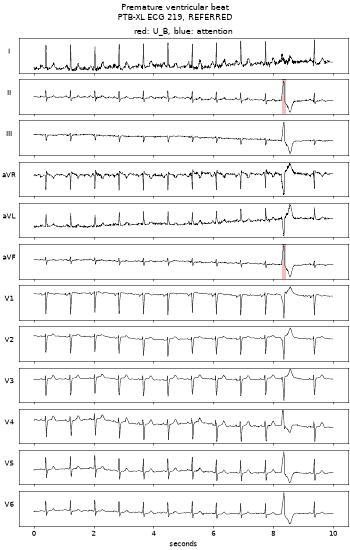

0.58 s for this ECG, plot included


In [6]:
started = time.perf_counter()
show(219, "Premature ventricular beat")
print(f"{time.perf_counter() - started:.2f} s for this ECG, plot included")

**What happened here.** ECG 219 is referred by its finding score, not by E: E is +0.07, just below its threshold of +0.24, but F (here z_PVC) is 6.99, far above 3.34. Because z_PVC is also above the switch (1.65), the explanation comes from the beat-wave map: two red marks, the QRS of the beat at 8.36 s in II and in aVF, the same premature beat and leads that notebook 12 marked. The whole run, plot included, took well under a second on the CPU (printed below the figure).

## 3. Every development ECG, by group

From the saved scores, over **all** development ECGs of each group (the groups of notebooks 11 and 12): the
share referred, and, among the referred ECGs, the share explained by each layer. The thresholds are the
ones above, set on the healthy group itself, so its referral rate is 5% by construction.

In [7]:
TEXT = {
    "AMI": "anterior myocardial infarction", "IMI": "inferior myocardial infarction",
    "ISCA": "anterior ischemia",
    "STTC": "non-specific ST/T change", "LVH": "left ventricular hypertrophy",
    "CLBBB": "complete left bundle branch block", "CRBBB": "complete right bundle branch block",
    "IRBBB": "incomplete right bundle branch block",
    "LAFB/LPFB": "left anterior or posterior fascicular block",
    "_AVB": "atrioventricular block", "WPW": "Wolff-Parkinson-White (pre-excitation)",
}
meta, statements = load_metadata(), load_statements()
diagnostic = statements[statements["diagnostic"] == 1]
subclass_of = diagnostic["diagnostic_subclass"].to_dict()
codes = meta["scp_codes"].apply(set)
subclasses = codes.apply(lambda found: {subclass_of[c] for c in found if c in subclass_of})
members = {
    "Healthy": healthy,
    "Benign variant": [i for i in ids if subclasses[i] == {"NORM"}
                       and codes[i] <= {"NORM", "SR", "SBRAD", "SARRH"} and codes[i] & {"SBRAD", "SARRH"}],
    "PVC (premature ventricular beat)": [i for i in ids if "PVC" in codes[i]],
    **{f"{name} ({text})": [i for i in ids if name in subclasses[i]] for name, text in TEXT.items()},
}
summary = {}
for group, found in members.items():
    rows = saved_scores.loc[found]
    chosen = rows[rows["referred"]]
    summary[group] = {"ECGs": len(rows), "referred": rows["referred"].mean(),
                      "referred by F alone": ((rows["F"] > F_THRESHOLD)
                                              & (rows["E"] <= E_THRESHOLD)).mean(),
                      "of referred: U_B (red)": (chosen["layer"] == 1).mean() if len(chosen) else np.nan}
    summary[group]["of referred: attention (blue)"] = 1 - summary[group]["of referred: U_B (red)"]
display(pd.DataFrame(summary).T.round(2).astype({"ECGs": int}))

,ECGs,referred,referred by F alone,of referred: U_B (red),of referred: attention (blue)
Healthy,463,0.05,0.00,0.05,0.95
Benign variant,52,0.08,0.00,0.00,1.00
PVC (premature ventricular beat),84,1.00,0.29,1.00,0.00
AMI (anterior myocardial infarction),229,0.97,0.00,0.52,0.48
IMI (inferior myocardial infarction),227,0.83,0.02,0.48,0.52
ISCA (anterior ischemia),66,0.98,0.00,0.42,0.58
STTC (non-specific ST/T change),152,0.68,0.02,0.35,0.65
LVH (left ventricular hypertrophy),136,0.79,0.00,0.53,0.47
CLBBB (complete left bundle branch block),40,1.00,0.00,0.57,0.43
CRBBB (complete right bundle branch block),37,1.00,0.00,0.43,0.57


**What the table shows.** Every PVC ECG is referred, 29% of them by F alone, and the switch explains all of them with the beat-wave map. Healthy ECGs are referred at the 5% budget and benign variants at 8%, almost all explained by attention. The cardiopathy groups are referred between 68% (non-specific ST/T change) and 100% of the time (both complete bundle branch blocks). Between 33% (incomplete right bundle branch block) and 57% (complete left bundle branch block) of each group's referred ECGs are explained by the beat-wave map, because z_PVC is above the switch for many ECGs without a PVC: 52% of referred anterior infarcts, for example.

In [8]:
def show_group(group: str, count: int) -> None:
    """Show the ``count`` lowest-numbered development ECGs of a group."""
    for ecg_id in sorted(members[group])[:count]:
        show(ecg_id, group)

## 4. Healthy hearts

Four healthy ECGs, then two benign variants (normal diagnosis with slow or irregular sinus rhythm). The
examples are the lowest-numbered ECGs of each group, as in notebooks 11 and 12, not hand-picked.

ECG 47 | not referred | E -4.33 (threshold +0.24) | F +1.29 (threshold 3.34) | z_PVC +1.18 (switch 1.65)


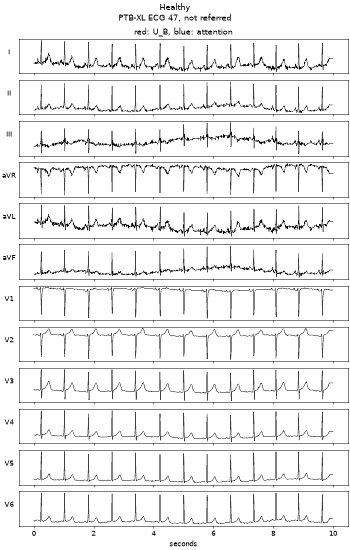

ECG 51 | not referred | E -4.05 (threshold +0.24) | F -0.49 (threshold 3.34) | z_PVC -1.27 (switch 1.65)


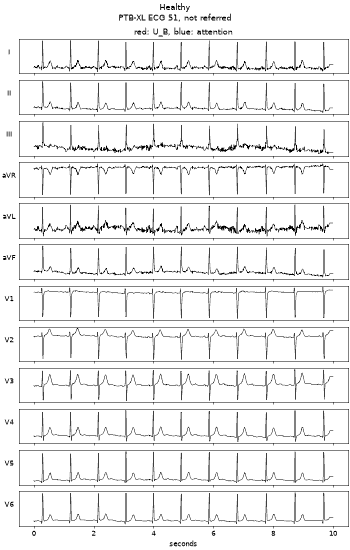

ECG 91 | not referred | E -5.25 (threshold +0.24) | F -0.06 (threshold 3.34) | z_PVC -0.06 (switch 1.65)


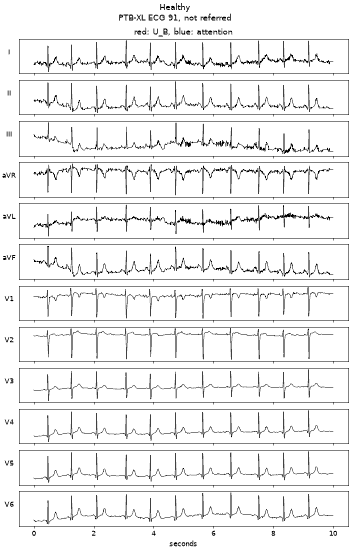

ECG 165 | not referred | E -4.91 (threshold +0.24) | F +1.21 (threshold 3.34) | z_PVC +0.17 (switch 1.65)


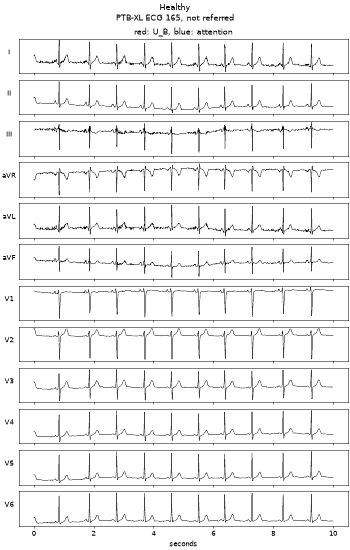

In [9]:
show_group("Healthy", 4)

None of the four healthy ECGs is referred: E is between -5.25 and -4.05, far below +0.24, and F is at most 1.29. Non-referred ECGs get no explanation, so their plots have no marks.

ECG 69 | not referred | E -1.17 (threshold +0.24) | F +0.90 (threshold 3.34) | z_PVC -0.36 (switch 1.65)


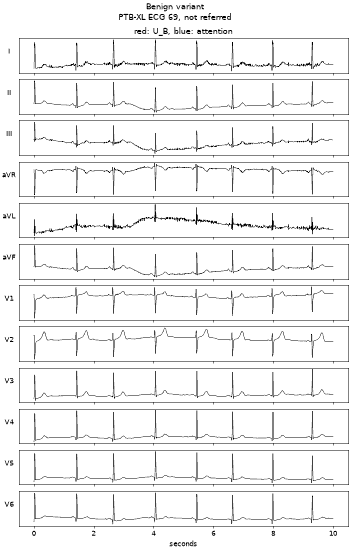

ECG 228 | not referred | E -4.59 (threshold +0.24) | F +0.86 (threshold 3.34) | z_PVC +0.41 (switch 1.65)


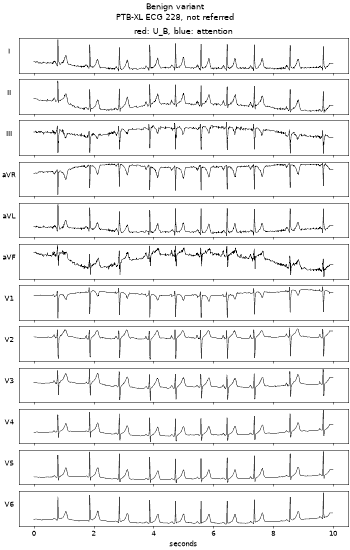

In [10]:
show_group("Benign variant", 2)

Neither benign variant is referred (E -1.17 and -4.59). Over all 52 benign variants, 8% are referred (section 3).

## 5. Different cardiopathies

Two ECGs per group, the lowest-numbered in the development set.

**Premature ventricular beat (PVC).** An early, wide beat that starts in the ventricles. The PVC finding head was trained for exactly this.

ECG 219 | REFERRED | E +0.07 (threshold +0.24) | F +6.99 (threshold 3.34) | z_PVC +6.99 (switch 1.65)
           | explained by the U_B beat-wave map (red): II QRS of the beat at 8.36 s; aVF QRS of the beat at 8.36 s


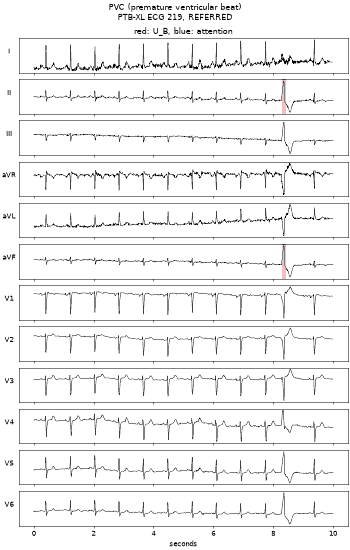

ECG 287 | REFERRED | E +8.29 (threshold +0.24) | F +6.94 (threshold 3.34) | z_PVC +6.94 (switch 1.65)
           | explained by the U_B beat-wave map (red): V1 ST of the beat at 9.10 s


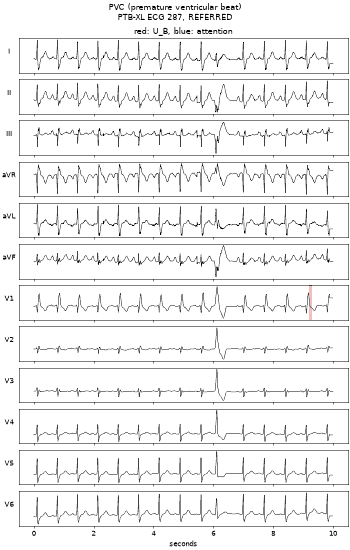

In [11]:
show_group("PVC (premature ventricular beat)", 2)

Both PVC examples are referred and explained by the beat-wave map, ECG 219 as above. ECG 287, which also has a complete left bundle branch block, gets one red mark, the ST of the beat at 9.10 s in V1, the same mark as in notebook 12.

**Anterior myocardial infarction.** Damage to the front wall, expected in V1-V4.

ECG 184 | REFERRED | E +7.02 (threshold +0.24) | F +1.71 (threshold 3.34) | z_PVC +1.71 (switch 1.65)
           | explained by the U_B beat-wave map (red): aVL P of the beat at 6.46 s


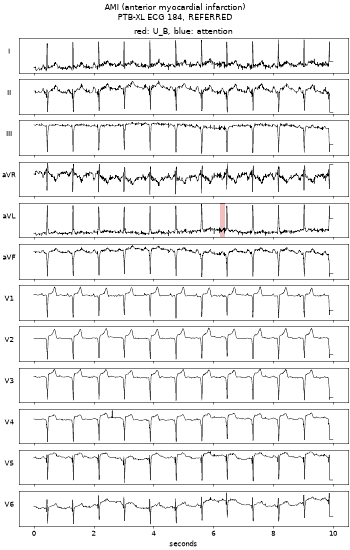

ECG 189 | REFERRED | E +7.75 (threshold +0.24) | F +0.76 (threshold 3.34) | z_PVC -0.12 (switch 1.65)
           | explained by the attention map (blue): II 7.4-7.6 s


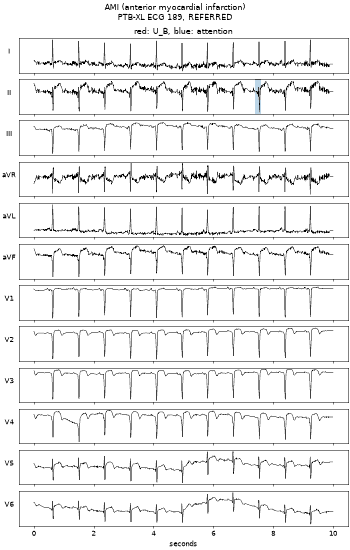

In [12]:
show_group("AMI (anterior myocardial infarction)", 2)

Both anterior infarcts are referred by E (+7.02 and +7.75). ECG 184 has z_PVC 1.71, just above the switch of 1.65, so the beat-wave map explains it, with one mark at the P wave of the beat at 6.46 s in aVL, not an anterior lead. ECG 189 goes to the attention map, which marks II at 7.4-7.6 s, also not an anterior lead.

**Inferior myocardial infarction.** Damage to the lower wall, expected in II, III and aVF (the attention map has only II of these).

ECG 8 | not referred | E -2.42 (threshold +0.24) | F -0.05 (threshold 3.34) | z_PVC -0.05 (switch 1.65)


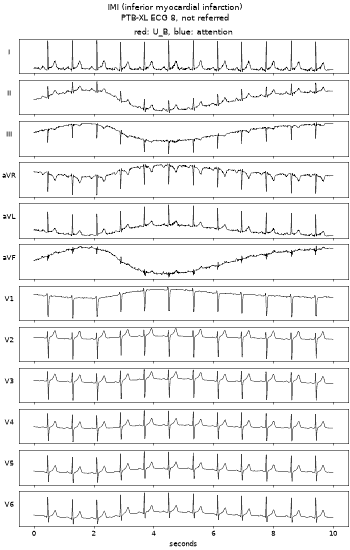

ECG 155 | not referred | E -0.31 (threshold +0.24) | F +1.28 (threshold 3.34) | z_PVC +1.28 (switch 1.65)


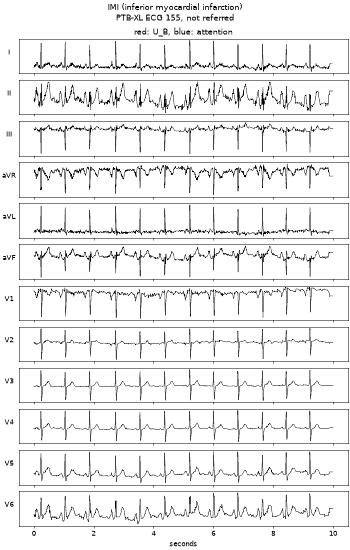

In [13]:
show_group("IMI (inferior myocardial infarction)", 2)

Neither inferior infarct is referred: ECG 8 has E -2.42 and ECG 155 has E -0.31, both below +0.24. Over the whole group, 83% are referred (section 3).

**Anterior ischemia.** ST depression or T-wave inversion in the front leads.

ECG 554 | REFERRED | E +2.08 (threshold +0.24) | F +0.82 (threshold 3.34) | z_PVC +0.82 (switch 1.65)
           | explained by the attention map (blue): V5 2.6-2.8 s


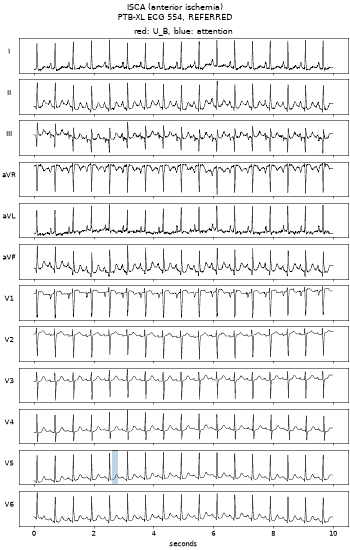

ECG 1427 | REFERRED | E +5.41 (threshold +0.24) | F +1.67 (threshold 3.34) | z_PVC +1.67 (switch 1.65)
           | explained by the U_B beat-wave map (red): V3 QRS of the beat at 9.27 s


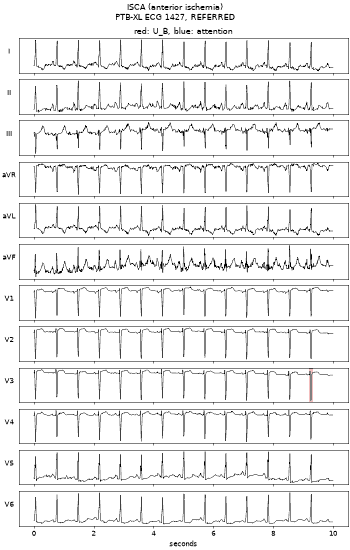

In [14]:
show_group("ISCA (anterior ischemia)", 2)

Both are referred. ECG 554 is explained by attention in V5 at 2.6-2.8 s. ECG 1427 has z_PVC 1.67, just above the switch, so the beat-wave map explains it: the QRS of the beat at 9.27 s in V3.

**Non-specific ST/T change.** Repolarization changes without a specific cause.

ECG 127 | not referred | E -0.89 (threshold +0.24) | F +1.35 (threshold 3.34) | z_PVC +0.26 (switch 1.65)


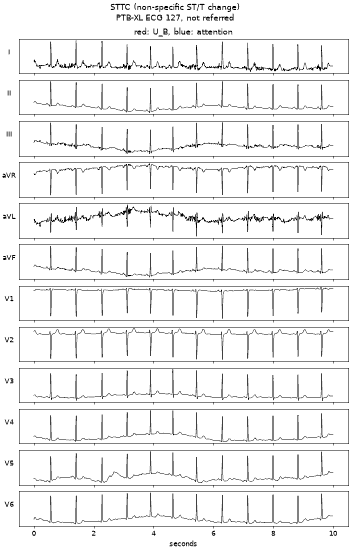

ECG 217 | REFERRED | E +0.86 (threshold +0.24) | F +1.54 (threshold 3.34) | z_PVC +1.54 (switch 1.65)
           | explained by the attention map (blue): V2 0.6-0.8 s


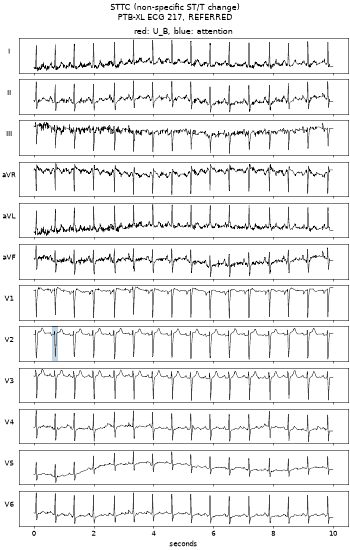

In [15]:
show_group("STTC (non-specific ST/T change)", 2)

ECG 127 is not referred (E -0.89). ECG 217 is referred (E +0.86) and explained by attention in V2 at 0.6-0.8 s. This group has the lowest referral rate, 68%.

**Left ventricular hypertrophy.** Tall QRS voltages, often with ST-T strain.

ECG 30 | not referred | E -0.69 (threshold +0.24) | F +0.49 (threshold 3.34) | z_PVC -0.18 (switch 1.65)


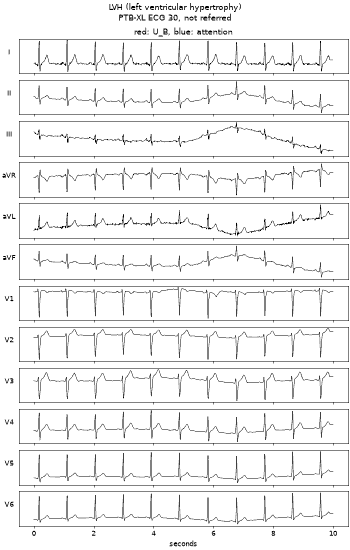

ECG 414 | REFERRED | E +9.16 (threshold +0.24) | F +0.08 (threshold 3.34) | z_PVC +0.08 (switch 1.65)
           | explained by the attention map (blue): I 8.8-9.0 s


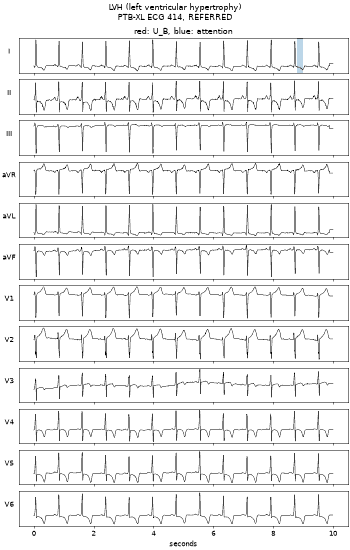

In [16]:
show_group("LVH (left ventricular hypertrophy)", 2)

ECG 30 is not referred (E -0.69). ECG 414 is referred with E +9.16 and explained by attention in lead I at 8.8-9.0 s.

**Complete left bundle branch block.** Every QRS is wide.

ECG 287 | REFERRED | E +8.29 (threshold +0.24) | F +6.94 (threshold 3.34) | z_PVC +6.94 (switch 1.65)
           | explained by the U_B beat-wave map (red): V1 ST of the beat at 9.10 s


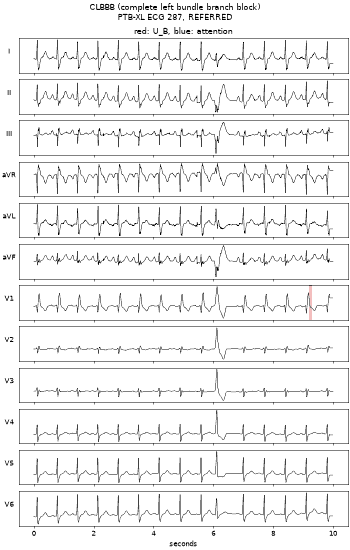

ECG 545 | REFERRED | E +8.02 (threshold +0.24) | F +0.93 (threshold 3.34) | z_PVC +0.89 (switch 1.65)
           | explained by the attention map (blue): I 8.8-9.0 s


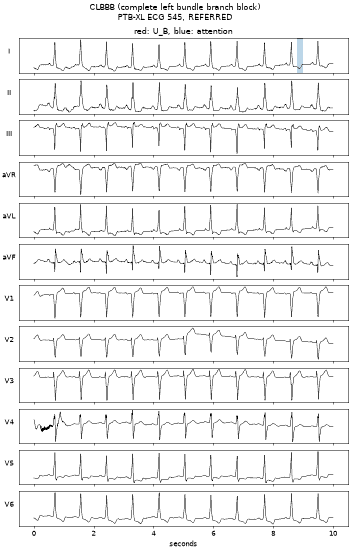

In [17]:
show_group("CLBBB (complete left bundle branch block)", 2)

ECG 287 is the PVC example above. ECG 545 (z_PVC 0.89) is explained by attention in lead I at 8.8-9.0 s. All 40 complete left bundle branch blocks are referred (section 3).

**Complete right bundle branch block.** Wide QRS with an rSR' pattern in V1.

ECG 1123 | REFERRED | E +7.42 (threshold +0.24) | F +0.51 (threshold 3.34) | z_PVC +0.51 (switch 1.65)
           | explained by the attention map (blue): V1 2.6-2.8 s


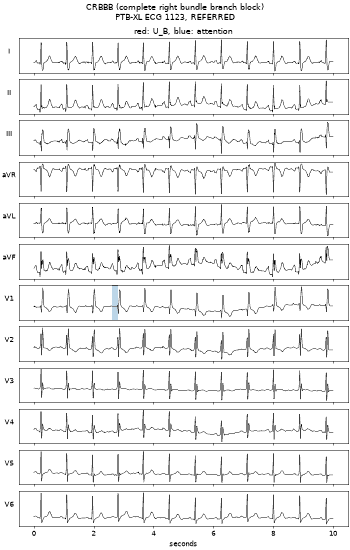

ECG 1478 | REFERRED | E +7.00 (threshold +0.24) | F -0.96 (threshold 3.34) | z_PVC -1.23 (switch 1.65)
           | explained by the attention map (blue): V1 0.8-1.0 s; V1 1.0-1.2 s; V1 2.6-2.8 s; V1 4.4-4.6 s; V1 5.4-5.6 s; V1 7.2-7.4 s; and 1 more


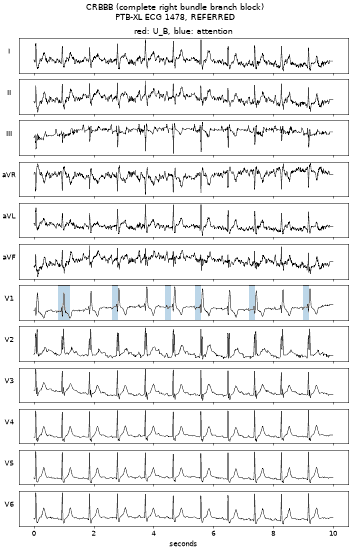

In [18]:
show_group("CRBBB (complete right bundle branch block)", 2)

Both are referred and explained by attention, both in V1: ECG 1123 at 2.6-2.8 s, and ECG 1478 in seven patches across the recording.

**Incomplete right bundle branch block.** A milder version, common in athletes.

ECG 483 | REFERRED | E +6.42 (threshold +0.24) | F +2.14 (threshold 3.34) | z_PVC +2.14 (switch 1.65)
           | explained by the U_B beat-wave map (red): V6 QRS of the beat at 5.21 s; V6 QRS of the beat at 5.79 s; V6 QRS of the beat at 6.38 s; V6 QRS of the beat at 6.96 s; V6 QRS of the beat at 7.54 s; V6 QRS of the beat at 8.11 s; and 2 more


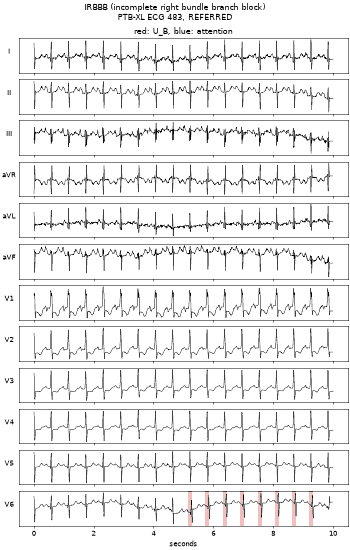

ECG 823 | REFERRED | E +3.43 (threshold +0.24) | F +11.92 (threshold 3.34) | z_PVC +11.92 (switch 1.65)
           | explained by the U_B beat-wave map (red): II P of the beat at 3.47 s; II QRS of the beat at 3.47 s; aVR P of the beat at 3.47 s; aVR QRS of the beat at 3.47 s; V1 P of the beat at 3.47 s; V1 QRS of the beat at 3.47 s; and 19 more


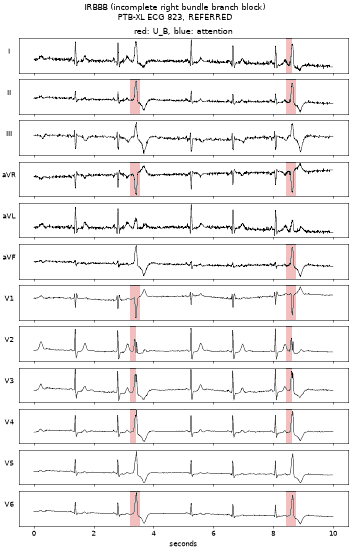

In [19]:
show_group("IRBBB (incomplete right bundle branch block)", 2)

ECG 483 (z_PVC 2.14) is explained by the beat-wave map: the QRS in V6 of eight beats from 5.21 s, the same pattern as in notebook 12. ECG 823 has z_PVC 11.92 and 25 marks; the six listed are the P and QRS waves of the beat at 3.47 s in II, aVR and V1.

**Fascicular block.** The QRS axis of every beat is shifted.

ECG 41 | REFERRED | E +3.13 (threshold +0.24) | F +1.07 (threshold 3.34) | z_PVC -0.30 (switch 1.65)
           | explained by the attention map (blue): II 2.4-2.6 s; II 3.2-3.4 s; II 4.0-4.2 s; II 9.0-9.2 s; II 9.8-10.0 s


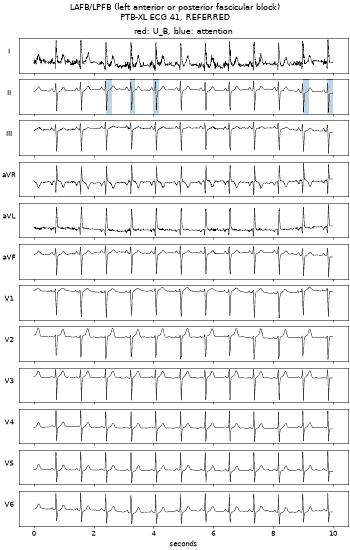

ECG 238 | REFERRED | E +2.28 (threshold +0.24) | F +2.51 (threshold 3.34) | z_PVC +2.51 (switch 1.65)
           | explained by the U_B beat-wave map (red): III QRS of the beat at 7.28 s


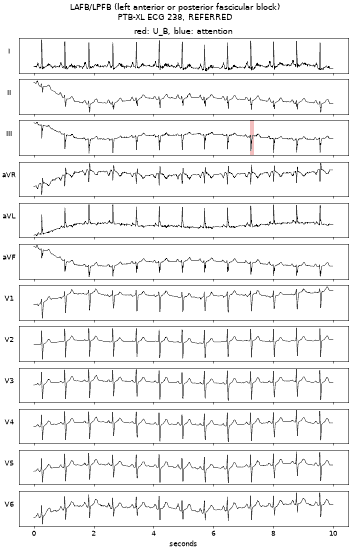

In [20]:
show_group("LAFB/LPFB (left anterior or posterior fascicular block)", 2)

Both are referred. ECG 41 is explained by attention in five patches of lead II. ECG 238 (z_PVC 2.51) is explained by the beat-wave map: the QRS of the beat at 7.28 s in III.

**Atrioventricular block.** A long PR interval or dropped beats.

ECG 234 | REFERRED | E +6.77 (threshold +0.24) | F +1.50 (threshold 3.34) | z_PVC +1.50 (switch 1.65)
           | explained by the attention map (blue): V4 6.2-6.4 s


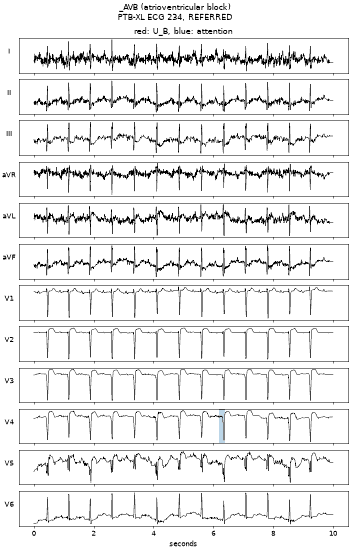

ECG 524 | REFERRED | E +1.72 (threshold +0.24) | F +1.30 (threshold 3.34) | z_PVC +1.30 (switch 1.65)
           | explained by the attention map (blue): V5 9.8-10.0 s


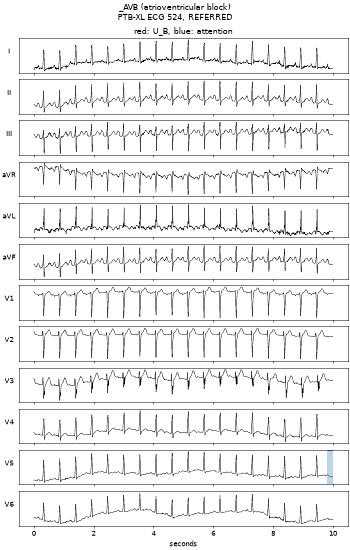

In [21]:
show_group("_AVB (atrioventricular block)", 2)

Both are referred and explained by attention: ECG 234 in V4 at 6.2-6.4 s, ECG 524 in V5 at 9.8-10.0 s.

**Wolff-Parkinson-White.** Short PR and a slurred QRS start in every beat. The WPW finding head was trained for it.

ECG 6240 | REFERRED | E +8.96 (threshold +0.24) | F +6.49 (threshold 3.34) | z_PVC +3.22 (switch 1.65)
           | explained by the U_B beat-wave map (red): III QRS of the beat at 0.56 s; aVL QRS of the beat at 0.56 s; III QRS of the beat at 1.32 s; aVL QRS of the beat at 1.32 s; III QRS of the beat at 2.08 s; aVL QRS of the beat at 2.08 s; and 22 more


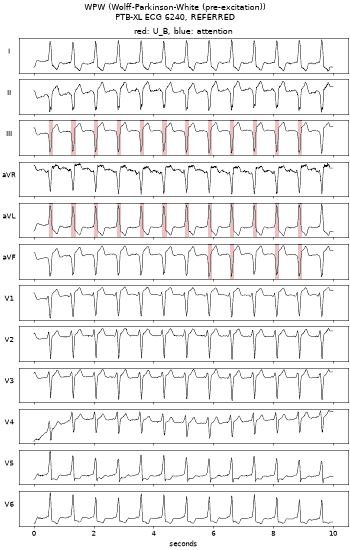

ECG 9699 | REFERRED | E +6.98 (threshold +0.24) | F +8.05 (threshold 3.34) | z_PVC +2.00 (switch 1.65)
           | explained by the U_B beat-wave map (red): aVF QRS of the beat at 7.10 s


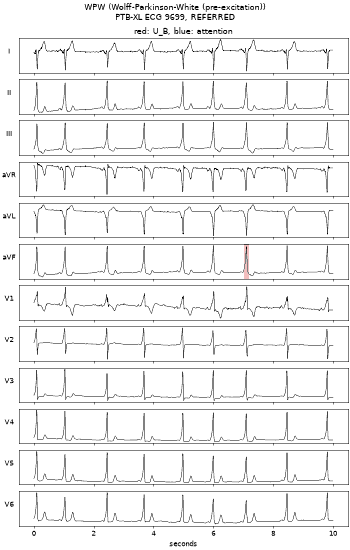

In [22]:
show_group("WPW (Wolff-Parkinson-White (pre-excitation))", 2)

Both are referred, and both have z_PVC above the switch (3.22 and 2.00), so the beat-wave map explains them. ECG 6240 gets the QRS in III and aVL beat after beat from 0.56 s (28 marks). ECG 9699 gets one mark, the QRS of the beat at 7.10 s in aVF. Their F (6.49 and 8.05) comes from the WPW head, but only z_PVC chooses the layer.

## 6. Do the live numbers equal the saved ones?

For every ECG shown above: the largest difference between this notebook's CPU result and the experiments'
saved values, and whether the referral decision is the same as with the saved scores.

In [23]:
checked = pd.DataFrame(checks).drop_duplicates("ECG")
print(f"{len(checked)} ECGs checked")
largest = checked[["E", "z_PVC", "z_WPW", "U_B scores", "attention map"]].max()
print("largest differences:", largest.map("{:.1e}".format).to_dict())
print("same referral decision for all:", bool(checked["same decision"].all()))

29 ECGs checked
largest differences: {'E': '1.0e-05', 'z_PVC': '4.0e-06', 'z_WPW': '2.0e-06', 'U_B scores': '0.0e+00', 'attention map': '3.2e-05'}
same referral decision for all: True


Over the 29 different ECGs scored live, E differs from the saved value by at most 1.0e-05, z_PVC by 4.0e-06, z_WPW by 2.0e-06 and the attention map by 3.2e-05, and the beat-wave scores are identical. Every referral decision is the same as with the saved scores. The live encoders ran on the CPU; the saved scores came from the GPU.

## 7. The experiments' numbers

**Experiment 046, primary screen.** SPH (a Chinese hospital, development data), evaluation half,
thresholds from 200 local normals, `combined_50` at 5%; means over 200 draws of local normals. "Other" ECGs
are neither normal nor abnormal by the label: sinus bradycardia or tachycardia, atrial premature beats and
similar.

In [24]:
summary046 = {(row["pipeline"], row["rule"], row["m"], row["budget"]): row for row in result046["summary"]}
contrasts046 = {(row["contrast"], row["rule"], row["m"], row["budget"], row["outcome"]): row
                for row in result046["contrasts"]}
outcomes = {"composite": "athlete-criteria abnormal caught", "binary_positive": "abnormal (label) caught",
            "normal": "normals referred", "other": "'other' ECGs referred"}
rows = {}
for outcome, label in outcomes.items():
    rows[label] = {pipeline: summary046[(pipeline, "combined_50", 200, 0.05)][outcome]["mean"]
                   for pipeline in ("v2", "v3", "v4")}
    found = contrasts046[("v4_minus_v3", "combined_50", 200, 0.05, outcome)]
    rows[label]["v4 - v3 [95% interval]"] = (f"{found['difference']:+.4f} "
                                             f"[{found['ci'][0]:+.4f}, {found['ci'][1]:+.4f}]")
display(pd.DataFrame(rows).T.round(4))
print("decision:", result046["reading"]["decision"])

,v2,v3,v4,v4 - v3 [95% interval]
athlete-criteria abnormal caught,0.789314,0.797319,0.809383,"+0.0121 [+0.0082, +0.0161]"
abnormal (label) caught,0.767642,0.776865,0.790628,"+0.0138 [+0.0094, +0.0183]"
normals referred,0.054543,0.057358,0.058171,"+0.0008 [-0.0017, +0.0032]"
'other' ECGs referred,0.22319,0.24875,0.274741,"+0.0260 [+0.0168, +0.0352]"


decision: adopt_v4


**Experiments 048 and 049, the explanation.** PTB-XL development ECGs referred by `combined_50` (on
pipeline v3's readout, Experiment 049). "Hit" is the share of the 73 PVC ECGs with a rule-detected
premature beat whose explanation is on that beat; the anterior contrast is how much more often anterior
infarcts are explained in V1-V4 than inferior infarcts; the last two columns count the referred infarcts
that the switch sends to the rhythm layer U_B.

In [25]:
case = result049["cases"]["combined_50_q0.975"]
names = {"pvc_switch": "PVC switch (048, used here)", "U_B": "U_B alone", "attention_jepa": "attention alone",
         "focal_switch": "focal switch (049)"}
rows = {}
for arm, label in names.items():
    found = case["maps"][arm]
    hmc, anterior = found["hit_minus_chance"], found["lead_contrast"]["anterior"]
    rows[label] = {"hit": found["hit_rate"], "chance": found["chance_rate"],
                   "hit - chance [95%]": f"{hmc['value']:+.3f} [{hmc['ci_low']:+.3f}, {hmc['ci_high']:+.3f}]",
                   "anterior contrast [95%]": (f"{anterior['value']:+.3f} "
                                               f"[{anterior['ci_low']:+.3f}, {anterior['ci_high']:+.3f}]")}
    sent = case["sent_to_U_B"].get(arm)
    for region in ("anterior", "inferior"):
        total = found["infarct_ecgs"][region]
        rows[label][f"{region} infarcts to U_B"] = f"{sent[region]} of {total}" if sent else ""
display(pd.DataFrame(rows).T.round(3))
print(f"referred: {case['referred']} ECGs")

,hit,chance,hit - chance [95%],anterior contrast [95%],anterior infarcts to U_B,inferior infarcts to U_B
"PVC switch (048, used here)",0.931507,0.197158,"+0.734 [+0.674, +0.787]","+0.183 [+0.059, +0.302]",68 of 136,47 of 116
U_B alone,0.931507,0.197158,"+0.734 [+0.674, +0.787]","+0.031 [-0.099, +0.162]",,
attention alone,0.027397,0.146575,"-0.119 [-0.156, -0.076]","+0.179 [+0.058, +0.290]",,
focal switch (049),0.424658,0.167841,"+0.257 [+0.158, +0.365]","+0.170 [+0.042, +0.288]",19 of 136,11 of 116


referred: 816 ECGs


## 8. Summary: what works, what does not, and what it costs

**What works.**

- On SPH, pipeline v4 caught 0.809 of the athlete-criteria abnormal ECGs against 0.797 for v3 (+0.0121 [+0.0082, +0.0161]), while referring about the same share of normals (5.8% against 5.7%).
- Every PVC ECG of the development set is referred (section 3). With the switch, the explanation is on the premature beat in 93% of the PVC ECGs with a rule-detected premature beat, as with the beat-wave map alone, and the attention map's infarct-lead contrast is kept (+0.183, against +0.031 for the beat-wave map alone).
- The whole pipeline runs on the CPU: one ECG took well under a second here, plot included (section 2), and the live scores equal the saved GPU scores to within 3.2e-5.

**What does not, and the costs.**

- **"Other" ECGs.** v4 refers 27.5% of the ECGs that are neither normal nor abnormal by the label (sinus bradycardia or tachycardia, atrial premature beats), against 24.9% for v3 and 22.3% for v2. At a student site many of these would be healthy students.
- **Infarcts explained by the rhythm map.** The PVC switch is not specific: it sends 68 of 136 referred anterior infarcts and 47 of 116 referred inferior infarcts to the beat-wave map. Anterior infarct 184 was explained by a P wave in aVL. 049's focal switch sent far fewer (19 and 11) but lost the premature beat in most PVC ECGs (hit 0.42).
- **Misses.** 4 of the 22 non-PVC cardiopathy examples were not referred: inferior infarcts 8 and 155, ST/T change 127 and hypertrophy 30. Non-specific ST/T changes are referred least (68%).
- **The marks are coarse.** Attention marks are 0.2 s patches in 8 leads, and several examples were marked in a lead where the finding is not expected (anterior infarct 189 in II). This notebook does not compare the marks with a cardiologist's reading.
- **The thresholds here come from PTB-XL's healthy development ECGs.** A clinic would set them on its own normal ECGs, so its referral rates would differ.